### Important Notes
* Make sure to install unite with the editable flag.
* If you want 64-bit precision in JAX, you need to set the relevant environment variable: "JAX_ENABLE_X64" = "1"

In [1]:
# some basic imports 
import os, sys, numpy, scipy, json
from astropy.table import Table
import jax, jaxlib
from unite.spectra import NIRSpecSpectra
from unite.fitting import NIRSpecFit 
from unite.utils import download_spectra
from dotfit import EmissionLines
os.environ['JAX_ENABLE_X64'] = '1' 

print(sys.version)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("jax:", jax.__version__)
print("jaxlib:", jaxlib.__version__)
print("Available backends:", jax.devices())
print('Emission loaded successfully:',len(EmissionLines().get_multiplet('[FeII]-9952')) == 2)

3.13.11 | packaged by conda-forge | (main, Jan 27 2026, 00:06:37) [Clang 19.1.7 ]
numpy: 2.4.1
scipy: 1.17.0
jax: 0.5.3
jaxlib: 0.5.3
Available backends: [CpuDevice(id=0)]
Emission loaded successfully: True


Here is an example of running the code to fit two dispersers for a single spectrum. You create the table of the sources and ensure that they get loaded in correctly. To make sure different dispersers are processed together they must share the same root and srcid. 

In [2]:
from pathlib import Path
spec_dir = 'spectra'
out_dir = 'out'
table_csv = '8204.csv'

spec_names = [
    'abell2744-greene-v4_g235m-f170lp_8204_45924.spec.fits',
#    'abell2744-greene-v4_g395m-f290lp_8204_45924.spec.fits',
#    'abell2744-greene-v4_prism-clear_8204_45924.spec.fits',
]

spec_table = download_spectra(
    spec_names,
    table_csv=table_csv,
    spectra_directory=spec_dir,   # where to place the file
)

# load spectra
spectra = NIRSpecSpectra(rows=spec_table)

# check to see what this table looks like
spec_table['srcid','file','root','grating','grade','z','spectra_directory']

srcid,file,root,grating,grade,z,spectra_directory
int64,str53,str19,str5,int64,float64,str7
45924,abell2744-greene-v4_g235m-f170lp_8204_45924.spec.fits,abell2744-greene-v4,G235M,3,4.4633,spectra


Now that we know how to load in the data, we can set up the fit itself. The emission lines (and their line types) that we want to fit need to be specified in a configuration file. 
Here you can also specify absorption or cauchy components. 

In [35]:
from dotfit import EmissionLines
from unite import defaults    
el = EmissionLines()
# explore lines like so
# el.get_table('[Fe II]',wave=[4000,4100])
# el.get_table(wave=[4000,4200])
# el.get_table('He I')
# el.get_multiplet('[FeII]-4083')

el.table['line_ratio'][el.table['key'] == 'CaII-3970'] = 0.25
el.get_multiplet('CaII-3935')


#-------------------------------------- [NeIII]
groups = [{'name': 'NeIII_gaussian'}]
#groups.append({'absorption': 'H7'}) 
groups.append({'emission': '[OII], H7,H8,H9,H10,H11,H12,H13'})
groups.append({'emission': '[NeIII]-3870*'})
groups.append({'outflow': '[NeIII]-3870*'})
groups.append({'emission': 'HeI-3821'}) #HeI-3873,HeI-3890
#groups.append({'narrow': 'CaII-3935*'}) 
#groups.append({'narrow': 'CaII-3935*'}) 
config = el.to_unite(groups, save=True)


with open(groups[0]['name']+'.json') as f:
    config = json.load(f)
config


config
el.get_multiplet('[NeIII]-3870')

name NeIII_gaussian


key,ion,wave_vac,Ei,Ek,Aki,fik,gigk,configuration,terms,Ji-Jk,type,wave_air,classification,gf,multiplet,line_ratio,multiplet_term,references,note
str14,str9,float64,float64,float64,float64,float64,str7,str37,str14,str9,str5,float64,str14,float64,int64,float64,str8,str4,str2
[NeIII]-3870,[Ne III],3869.86,0.0,3.203841,0.174,3.91e-10,5-5,2s22p4-2s22p4,3P-1D,2-2,M1,3868.7632045705686,forbidden,1.955e-09,1,1.0,3P-1D,NIST,--
[NeIII]-3969,[Ne III],3968.59,0.0797065,3.203841,0.054,2.13e-10,3-5,2s22p4-2s22p4,3P-1D,1-2,M1,3967.4674744940608,forbidden,6.39e-10,1,1.0,3P-1D,NIST,--


Running the fit is now easy! We use MCMC sampling as implemented in numpyro NUTS. Let's use 500 samples for warm-up, and 1000 for the actual sampling.

The fitting produces some files that store the full chains and a summary of results, and also a figure showing the fit. You can choose the location where to store these files.

In [33]:
# modified defaults
import unite.defaults as defaults   
defaults.CONTINUUM = defaults.LINEPAD # less padding
defaults.fwhm['emission'] = (0, 500)
defaults.fwhm['outflow'] = (700, 2500)
defaults.flux['outflow'] = (0, 2)
defaults.redshift['outflow'] = (-0.05,0.0)

# Run the fit and get results object
results = NIRSpecFit(config, spec_table, spectra, out_dir, N=200, num_warmup=100, rescale_errors=False)

# results object contains:
# - results.npz_path: full MCMC samples
# - results.csv_path: parameter summary CSV
# - results.fits_path: parameter summary FITS
# - results.samples: lazy-loaded samples dict
# - results.print(): formatted parameter table
#results.print()


sample: 100%|██████████| 300/300 [00:04<00:00, 74.30it/s, 255 steps of size 6.59e-03. acc. prob=0.86] 
/Users/ivo/Astro/PROJECTS/UNCOVER/sci/deep/unite/unite/fitting.py:313: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(logL).mean(axis=0)).sum() - logL.var(axis=0, ddof=1).sum()
/Users/ivo/Astro/PROJECTS/UNCOVER/sci/deep/unite/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


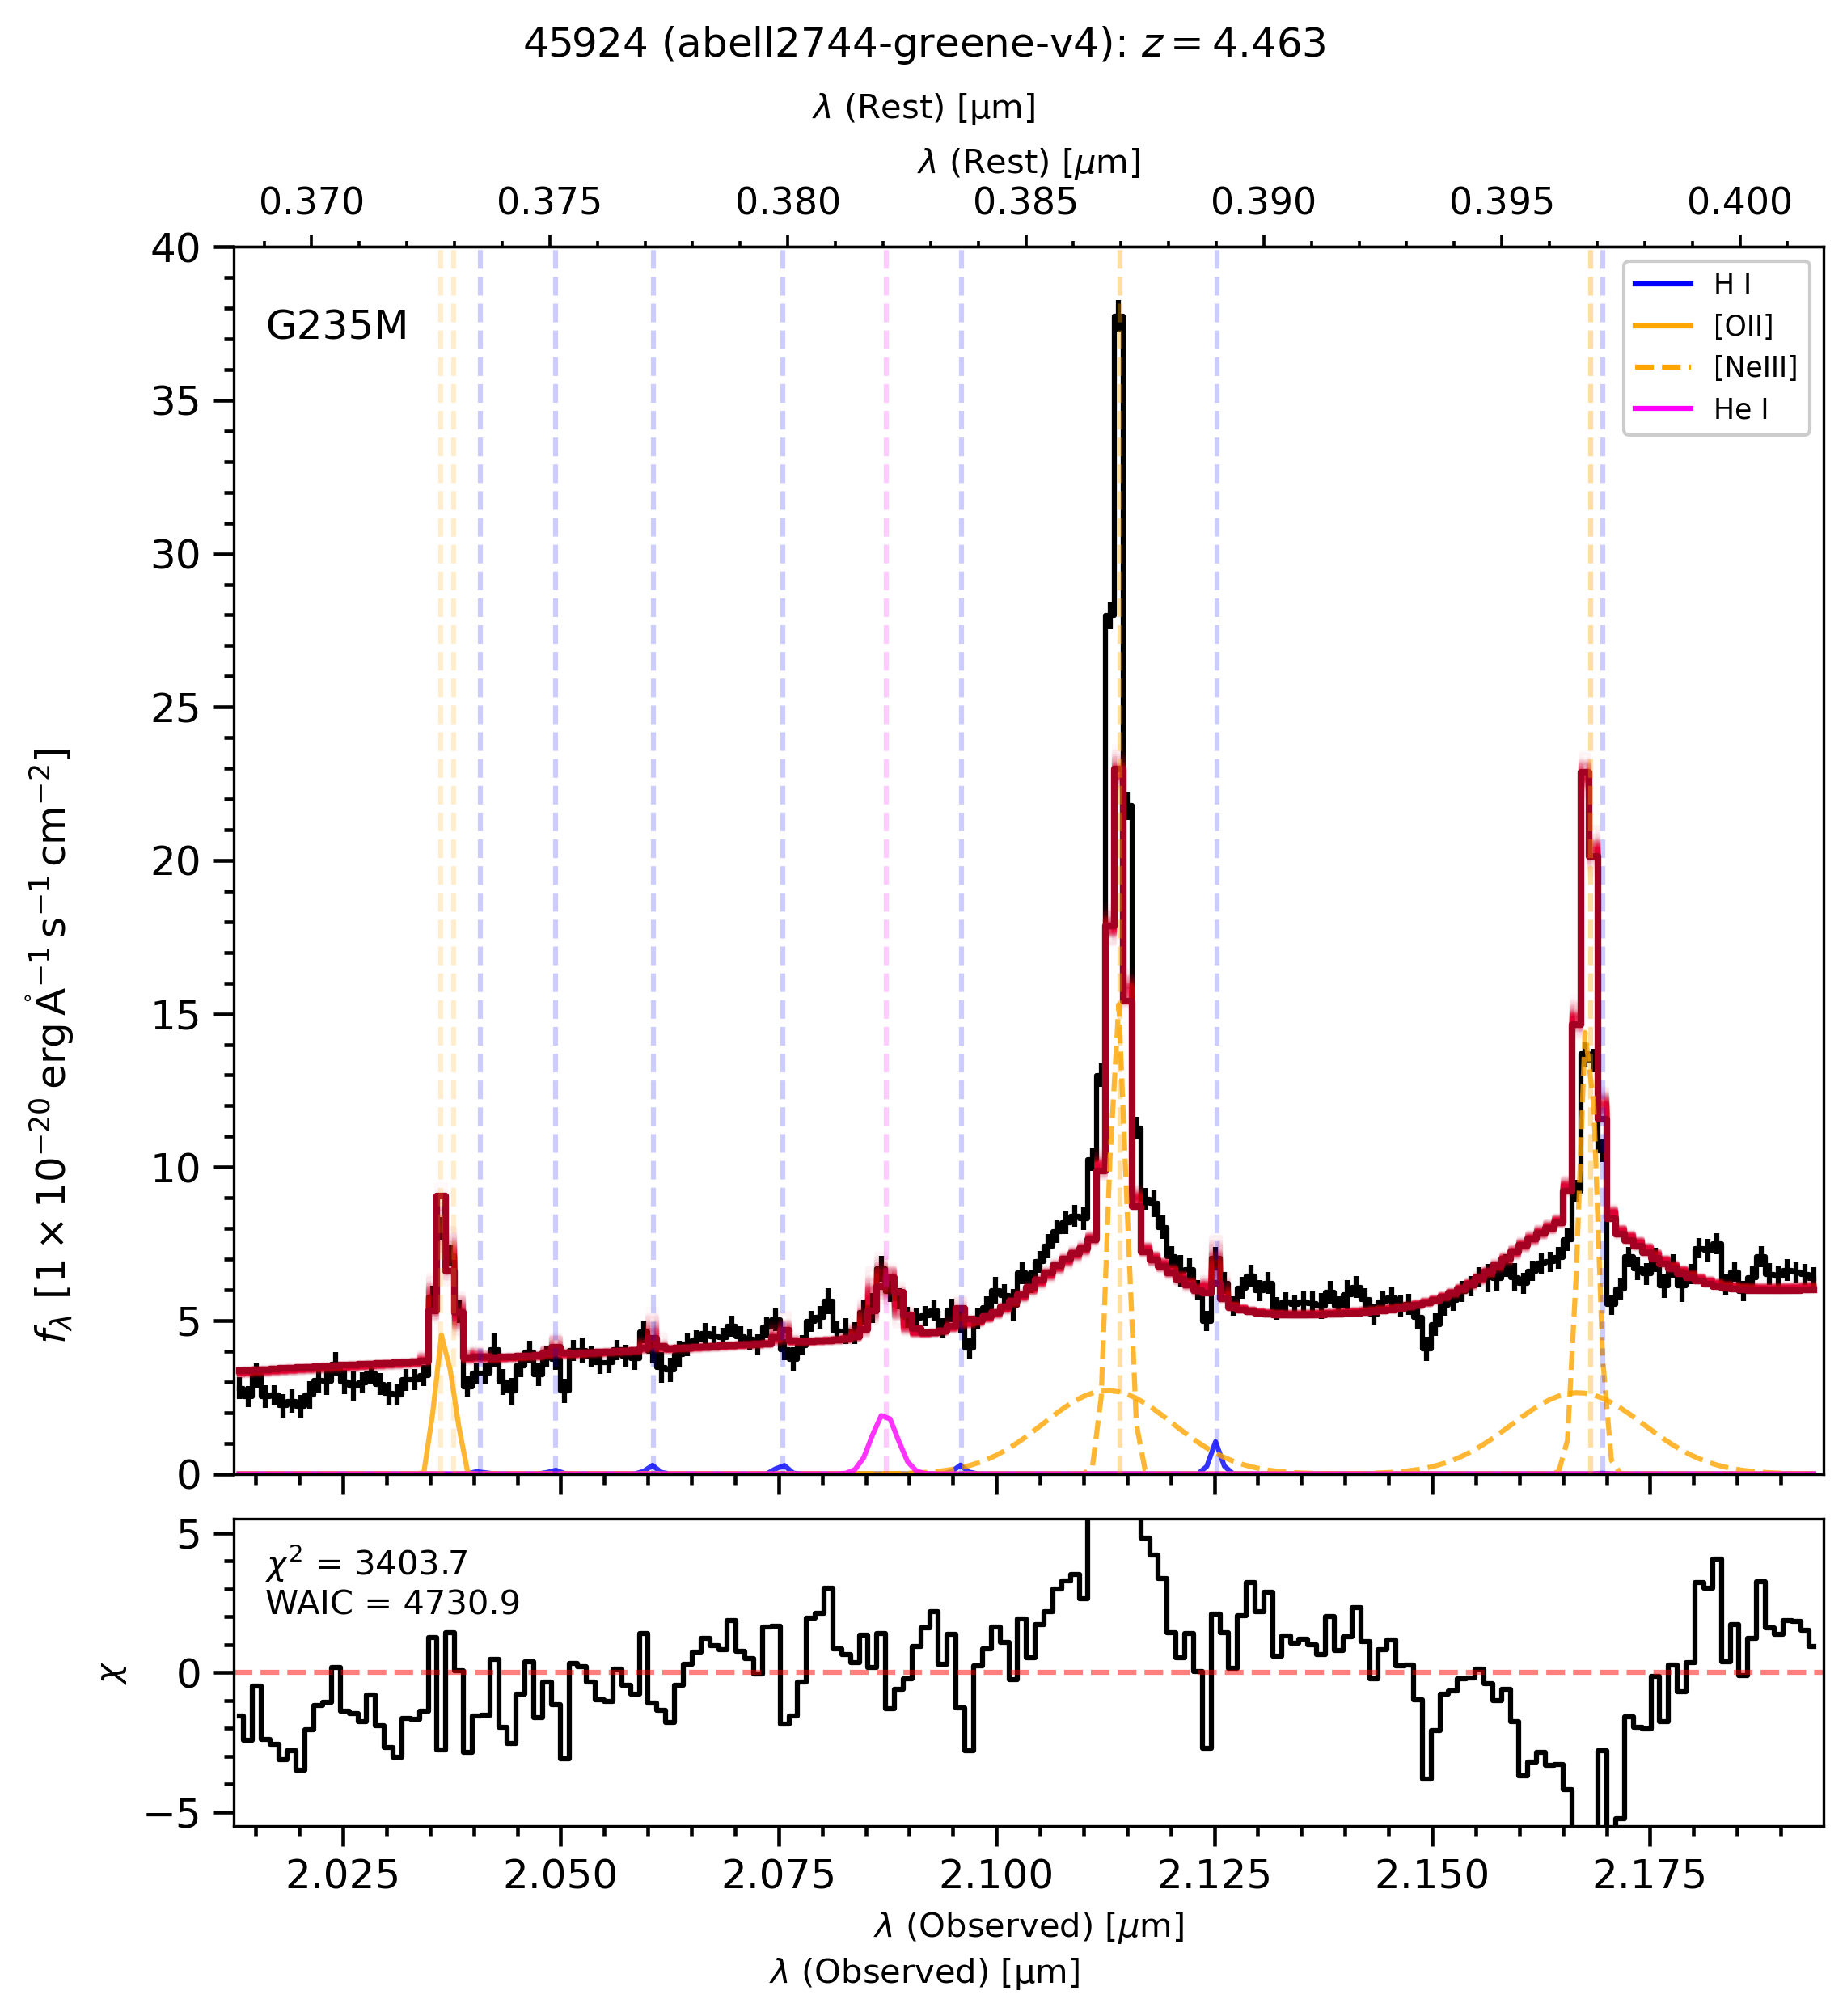

In [34]:
import importlib
import unite.plotting
importlib.reload(unite.plotting)
importlib.reload(sys.modules['unite.fitting'])
from unite.plotting import plotResults

# recreate the output plots with other plotting options
plot_kw={"yscale": "linear","ylim":[0,40],'show_lines':True} 

# data contains the samples, components, best model in|dex, and spectra information
fig, data = plotResults(config, rows=spec_table, output_dir=out_dir, plot_kwargs=plot_kw)
fig

(0.0, 20.0)

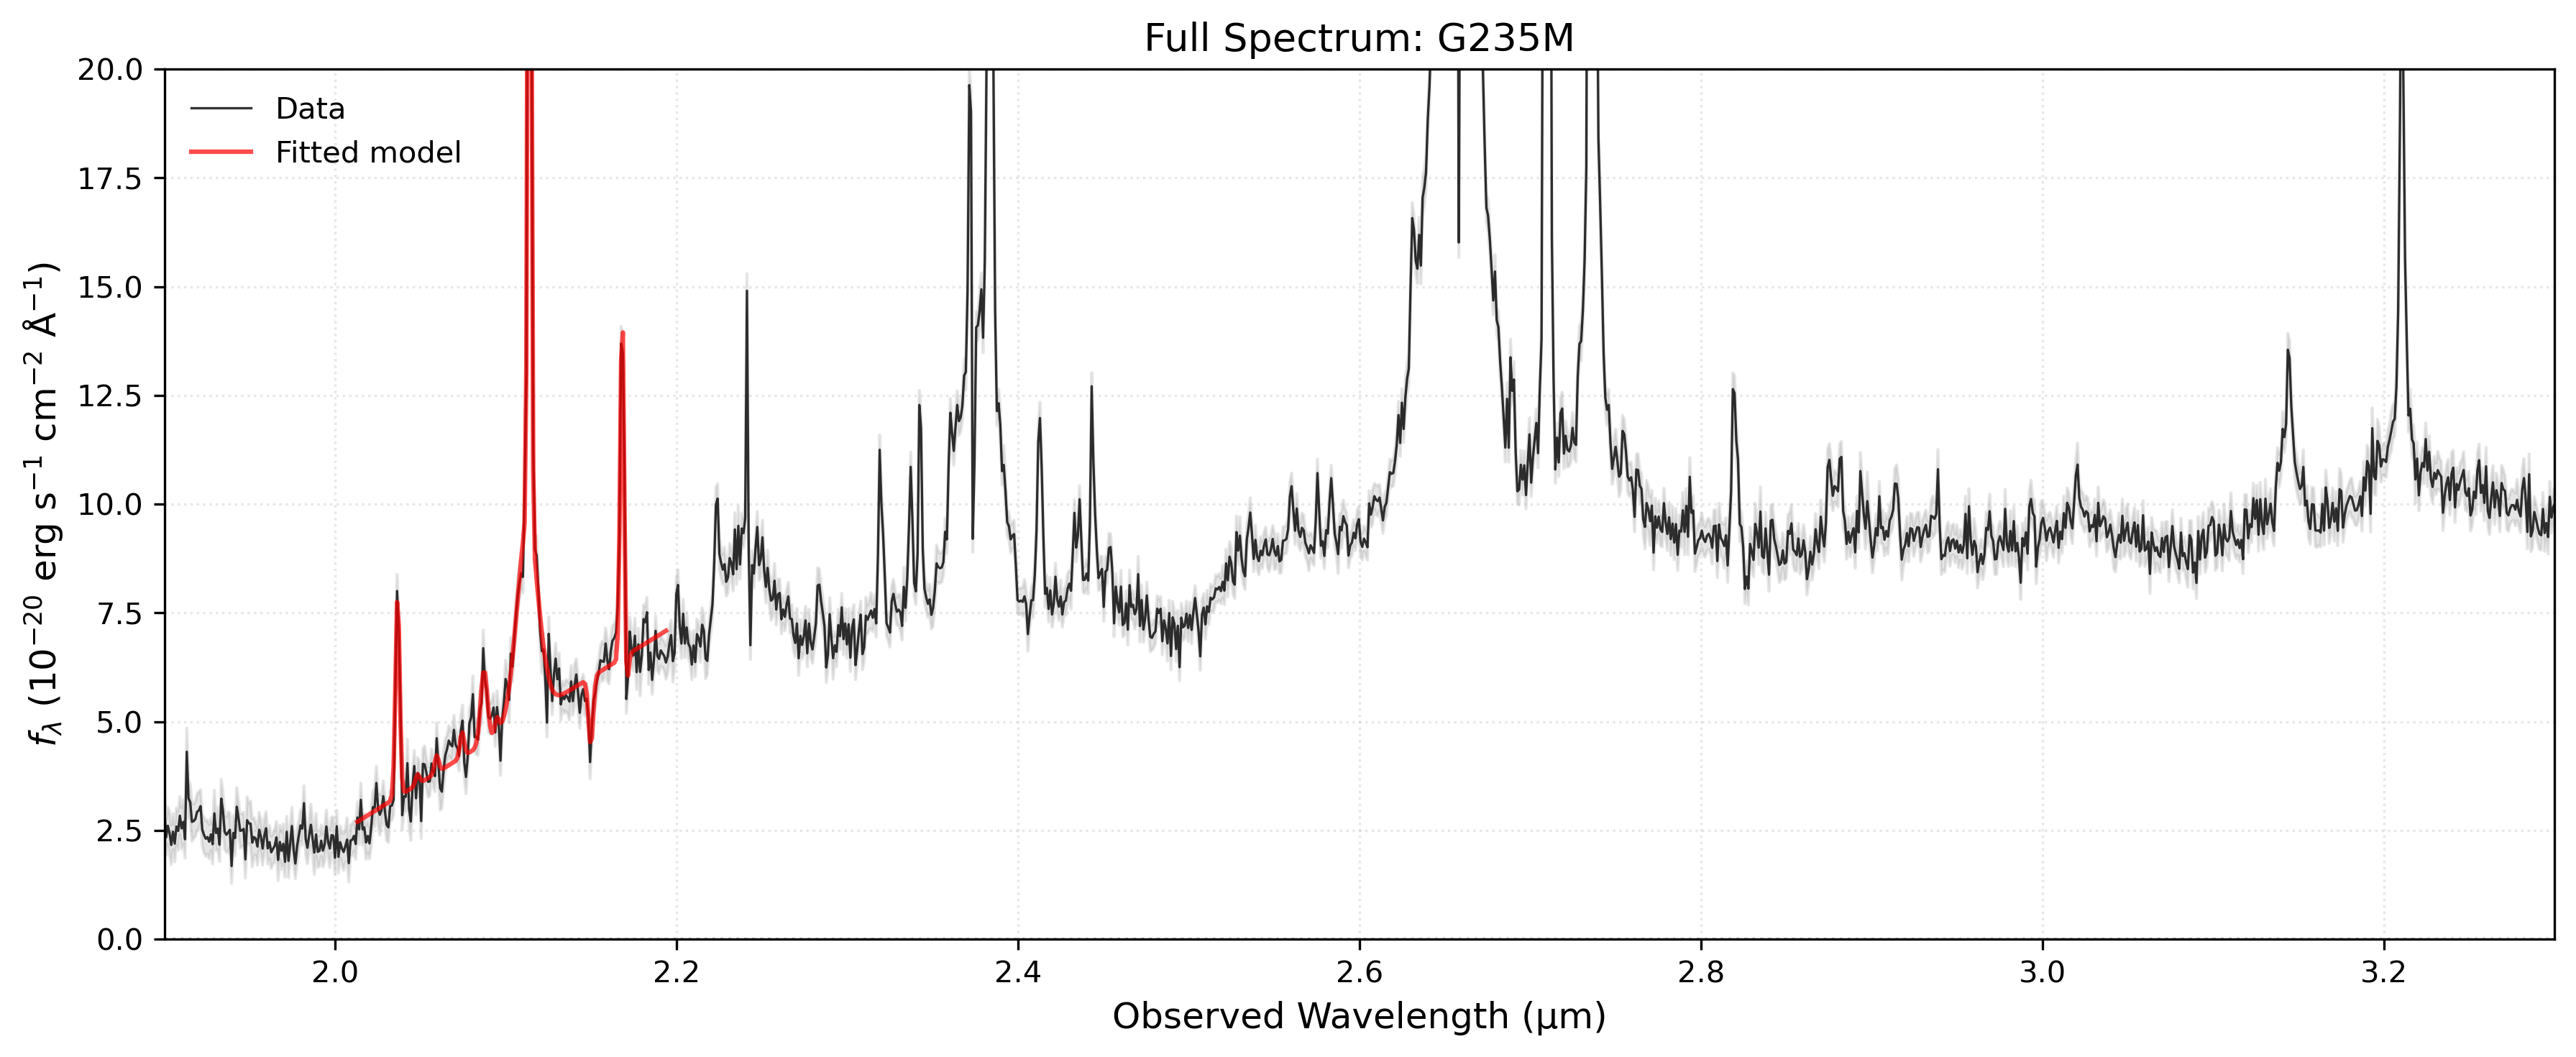

In [10]:
from unite.plotting import plotFullSpectrum
fig, ax = plotFullSpectrum(
    config=config,
    rows=spec_table,  # Use suite.rows, NOT spec_table_val!
    output_dir='out',
    wavelength_range=(1.7, 3.8),  # Optional: zoom to range
)
ax.set_xlim(1.9,3.3)
ax.set_ylim(0.,20.)

* To change the *shape* of the priors we can edit the unite/priors.py file directly

* To change the *range* of the priors we can edit the unite/defaults.py file directly

* To change the width of the wavelength range used to fit, or the width used to find an initial estimate of the line fluxes, we can edit the unite/defaults.py file directly


In [8]:
fig = results.corner(max_lines=5)  # Show 10 brightest lines
fig.savefig('corner_plot.png', dpi=150, bbox_inches='tight')
print("Corner plot saved to corner_plot.png")

Corner plot saved to corner_plot.png
